In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pywaffle import Waffle
con = sqlite3.connect('f1_data.db')

# Reading info from database using SQL query

In [3]:
results = pd.read_sql_query("""
                            SELECT  r.race_Id, r.driver_id,d.full_name, c.name as constructor_name, r.grid_position, r.finish_position, r.points, q.q1,q.q2,q.q3, rc.race_name, rc.season
                            From race_results as r
                            inner join drivers as d on r.driver_id = d.driver_Id
                            inner join constructors as c on r.constructor_id = c.constructor_id
                            inner join qualifying_results as q on r.race_Id = q.race_Id and r.driver_id = q.driver_Id
                            inner join races as rc on r.race_id = rc.race_id 
                            """, con)

results.head()


,race_id,driver_id,full_name,constructor_name,grid_position,finish_position,points,q1,q2,q3,race_name,season
0,202101,HAM,Lewis Hamilton,Mercedes,2.0,1.0,25.0,0 days 00:01:30.617000,0 days 00:01:30.085000,0 days 00:01:29.385000,Bahrain Grand Prix,2021
1,202101,VER,Max Verstappen,Red Bull Racing,1.0,2.0,18.0,0 days 00:01:30.499000,0 days 00:01:30.318000,0 days 00:01:28.997000,Bahrain Grand Prix,2021
2,202101,BOT,Valtteri Bottas,Mercedes,3.0,3.0,16.0,0 days 00:01:31.200000,0 days 00:01:30.186000,0 days 00:01:29.586000,Bahrain Grand Prix,2021
3,202101,NOR,Lando Norris,McLaren,7.0,4.0,12.0,0 days 00:01:30.902000,0 days 00:01:30.099000,0 days 00:01:29.974000,Bahrain Grand Prix,2021
4,202101,PER,Sergio Perez,Red Bull Racing,0.0,5.0,10.0,0 days 00:01:31.165000,0 days 00:01:30.659000,None,Bahrain Grand Prix,2021


# Handling missing data 

In [4]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   race_id           1659 non-null   int64  
 1   driver_id         1659 non-null   object 
 2   full_name         1659 non-null   object 
 3   constructor_name  1659 non-null   object 
 4   grid_position     1397 non-null   float64
 5   finish_position   1397 non-null   float64
 6   points            1400 non-null   float64
 7   q1                1227 non-null   object 
 8   q2                918 non-null    object 
 9   q3                605 non-null    object 
 10  race_name         1659 non-null   object 
 11  season            1659 non-null   int64  
dtypes: float64(3), int64(2), object(7)
memory usage: 155.7+ KB


In [5]:
results.describe()

,race_id,grid_position,finish_position,points,season
count,1659.000000,1397.000000,1397.000000,1400.000000,1659.000000
mean,202251.860759,10.200429,10.479599,5.058214,2022.408680
std,108.126514,5.820247,5.757683,7.218533,1.086965
min,202101.000000,0.000000,1.000000,0.000000,2021.000000
25%,202121.000000,5.000000,5.000000,0.000000,2021.000000
50%,202220.000000,10.000000,10.000000,0.250000,2022.000000
75%,202319.000000,15.000000,15.000000,9.000000,2023.000000
max,202417.000000,20.000000,20.000000,26.000000,2024.000000


In [6]:
print(results["finish_position"].isna().sum())

262


In [7]:
print(results["grid_position"].isna().sum())

262


I found **262** null valueі in "finish_position" and in "grid_position" column. I didn't find any information about those races, there are some results in the Internet, but no info in API, I think it is relevant to drop those values, because they will not affect by any way on the future analysis 

In [8]:
results = results.dropna(subset=["finish_position"])

In [9]:
results.isna().sum()

race_id               0
driver_id             0
full_name             0
constructor_name      0
grid_position         0
finish_position       0
points                0
q1                  212
q2                  509
q3                  812
race_name             0
season                0
dtype: int64

Now, we are sure that there are no null value in positions, and points, then we have to handle q1,q2,q3 null values. We will replace null to 0, because null means that drivers didn't get to q2  or q3. Or they didn't start the sessions, and the started from the back.

In [10]:
results["q1"].replace({np.nan: 0}, inplace=True)
results["q2"].replace({np.nan: 0}, inplace=True)
results["q3"].replace({np.nan: 0}, inplace=True)

In [11]:
results.isna().sum()

race_id             0
driver_id           0
full_name           0
constructor_name    0
grid_position       0
finish_position     0
points              0
q1                  0
q2                  0
q3                  0
race_name           0
season              0
dtype: int64

We handled missing data, we can move on to EDA

# EDA

First important thing I wanted to see is correlation between quali results and race results

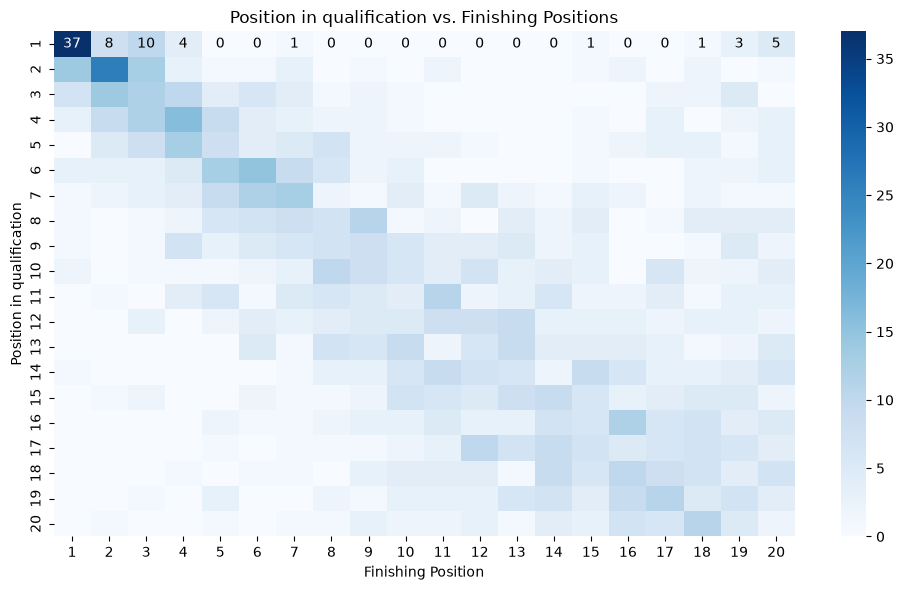

In [12]:
plot_data = results[["grid_position", "finish_position"]].copy()
plot_data["grid_position"] = plot_data["grid_position"].astype(int)
plot_data["finish_position"] = plot_data["finish_position"].astype(int)

heatmap_data = pd.crosstab(
    plot_data["grid_position"],
    plot_data["finish_position"]
).reindex(index=range(1, 21), columns=range(1, 21), fill_value=0)

plt.figure(figsize=(10, 6))
ax =sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=False,
    fmt="d",
    cbar=True,
    linewidths= 0
)

for col, value in enumerate(heatmap_data.iloc[0]):
    ax.text(
        col + 0.5,
        0.5,
        int(value),
        ha="center",
        va="center",
        color="white" if value > heatmap_data.values.max() / 2 else "black"
    )

plt.title("Position in qualification vs. Finishing Positions")
plt.xlabel("Finishing Position")
plt.ylabel("Position in qualification") 
plt.tight_layout()
plt.show()


It is can be seen that position in qualification very often determines your finishing position. Sometimes it is as important as the race

*The next very interesting point to look at is which of the drivers has the highest realisation of its grid position* 

In [13]:
results_analysis = results.copy()
results_analysis["avg_gained_positions"] =results_analysis.groupby("driver_id")["grid_position"].transform(lambda x: (x - results_analysis["finish_position"]).mean())

avg_gained_postions_rank = results_analysis[["full_name", "avg_gained_positions"]].drop_duplicates().sort_values(by="avg_gained_positions", ascending=False).head(10)
avg_gained_postions_rank

,full_name,avg_gained_positions
1630,Franco Colapinto,6.000000
1346,Oliver Bearman,4.000000
254,Robert Kubica,2.000000
1132,Liam Lawson,1.600000
891,Logan Sargeant,1.307692
9,Lance Stroll,1.173913
19,Nikita Mazepin,0.666667
748,Nyck De Vries,0.545455
1,Max Verstappen,0.528571
470,Guanyu Zhou,0.416667


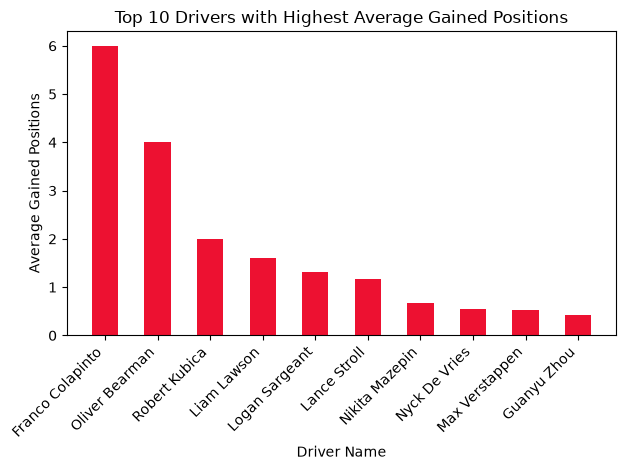

In [14]:
plt.bar(avg_gained_postions_rank["full_name"], avg_gained_postions_rank["avg_gained_positions"], color='#ED1131', width=0.5)
plt.title("Top 10 Drivers with Highest Average Gained Positions")
plt.xlabel("Driver Name")
plt.ylabel("Average Gained Positions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Next we will look at the number of gained points by drivers and then the teams

In [15]:
results_analysis["sum_of_points"] = results_analysis.groupby("driver_id")["points"].transform("sum")
top_gained_points = results_analysis[["full_name","sum_of_points"]].drop_duplicates().sort_values(by="sum_of_points", ascending=False).head(10)
top_gained_points

,full_name,sum_of_points
1,Max Verstappen,1439.5
0,Lewis Hamilton,880.5
4,Sergio Perez,774.0
5,Charles Leclerc,659.0
7,Carlos Sainz,582.5
3,Lando Norris,549.0
13,George Russell,455.0
18,Fernando Alonso,389.0
2,Valtteri Bottas,268.0
12,Esteban Ocon,203.0


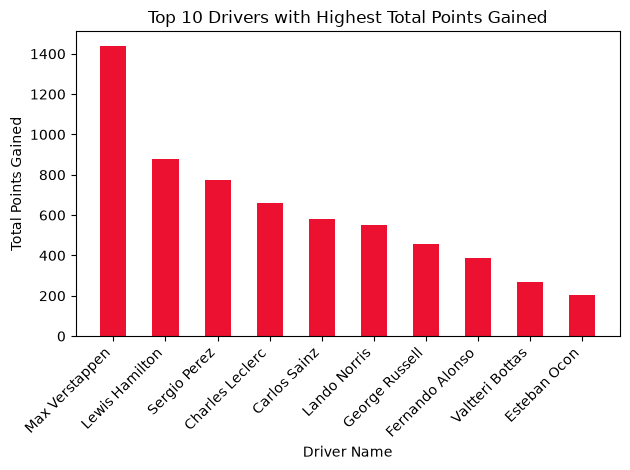

In [16]:
plt.bar(top_gained_points["full_name"], top_gained_points["sum_of_points"], color='#ED1131', width=0.5)
plt.title("Top 10 Drivers with Highest Total Points Gained")
plt.xlabel("Driver Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Let's see how much points did Max Verstappen take from all of the points for these years

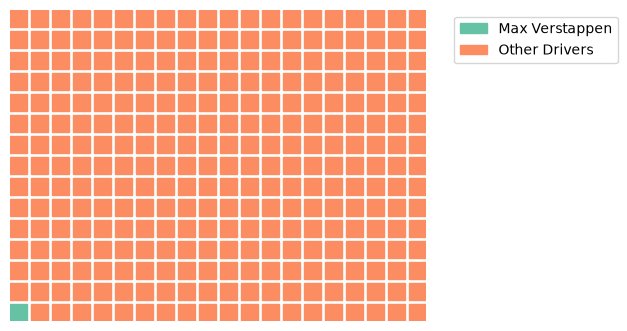

In [17]:
max_points = results_analysis["sum_of_points"].where(results_analysis["full_name"]=="Max Verstappen").dropna().values[0]
data={
    "Max Verstappen": max_points,
    "Other Drivers": results_analysis["sum_of_points"].sum() - max_points
}
plt.figure(
    FigureClass=Waffle,
    rows=15,
    columns=20,
    values=data,
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
)
plt.show()

In [18]:
percentage_max = (max_points / results_analysis["sum_of_points"].sum()) * 100
print(percentage_max)

0.30013875814070345


Although, Max has the highest number of points, it is still 0.3% of all points gained from 2021 to 2024

In [19]:
results_analysis["sum_of_points_constructor"] = results_analysis.groupby("constructor_name")["points"].transform("sum")
top_gained_points_by_constructor = results_analysis[["constructor_name","sum_of_points_constructor"]].drop_duplicates().sort_values(by="sum_of_points_constructor", ascending=False).head(10)
top_gained_points_by_constructor

,constructor_name,sum_of_points_constructor
1,Red Bull Racing,2213.5
0,Mercedes,1538.5
5,Ferrari,1247.5
3,McLaren,859.0
9,Aston Martin,433.0
12,Alpine,419.0
8,AlphaTauri,189.0
10,Alfa Romeo,73.0
13,Williams,59.0
15,Haas F1 Team,43.0


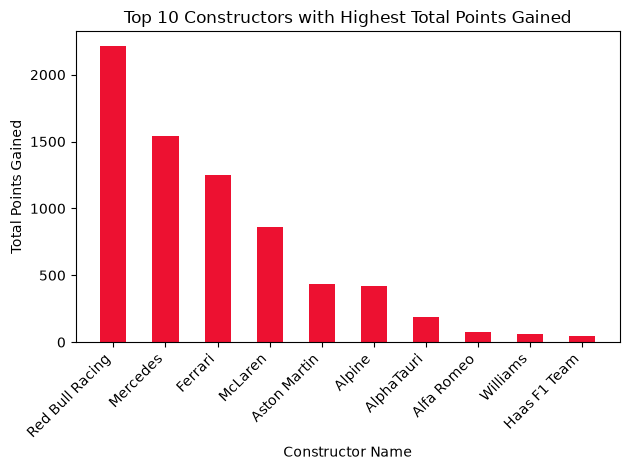

In [20]:
plt.bar(top_gained_points_by_constructor["constructor_name"], top_gained_points_by_constructor["sum_of_points_constructor"], color='#ED1131', width=0.5)
plt.title("Top 10 Constructors with Highest Total Points Gained")
plt.xlabel("Constructor Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

We can see that if we would compare Max Verstappen to the whole teams(excluding his team Red Bull Racing), Max would be on the second place with 99 points difference with Mercedes team. 

Lets visualize it

In [21]:
results_analysis_1 = results_analysis.copy()
max_points_df = pd.DataFrame({"constructor_name": ["Max Verstappen"], "sum_of_points_constructor": max_points})
results_analysis_1 = pd.concat([results_analysis_1,max_points_df], ignore_index=True)
results_analysis_1 = results_analysis_1.sort_values(by="sum_of_points_constructor", ascending=False).drop_duplicates(subset=["constructor_name"], keep="first")
results_analysis_1 = results_analysis_1[["constructor_name","sum_of_points_constructor"]].head(10)
results_analysis_1

,constructor_name,sum_of_points_constructor
824,Red Bull Racing,2213.5
402,Mercedes,1538.5
1397,Max Verstappen,1439.5
576,Ferrari,1247.5
260,McLaren,859.0
667,Aston Martin,433.0
1085,Alpine,419.0
313,AlphaTauri,189.0
1115,Alfa Romeo,73.0
435,Williams,59.0


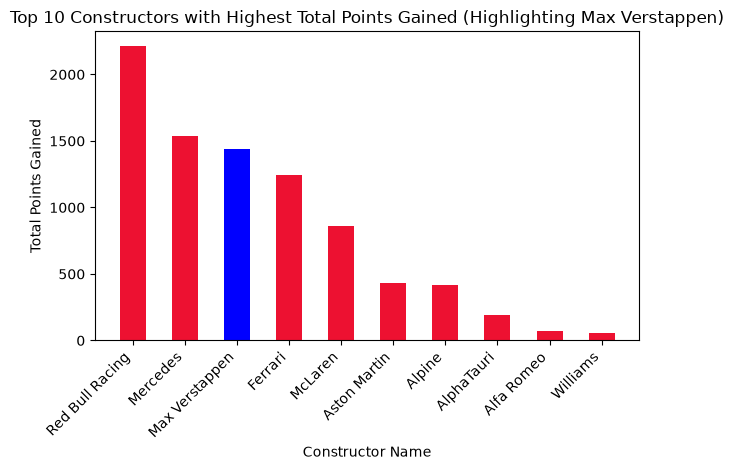

In [22]:
plt.bar(results_analysis_1["constructor_name"], results_analysis_1["sum_of_points_constructor"], width=0.5, color=['blue' if name == "Max Verstappen" else '#ED1131' for name in results_analysis_1["constructor_name"]])
plt.title("Top 10 Constructors with Highest Total Points Gained (Highlighting Max Verstappen)")
plt.xlabel("Constructor Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now, we will see what the difference is from 2022-2024, because 2021 was a year where the Max's domination has not started yet.

In [23]:
results_analysis["sum_of_points_after_2021"] = results_analysis.where(lambda x: results_analysis["season"] > 2021).groupby("driver_id")["points"].transform("sum")
results_analysis_after_2021 = results_analysis[["full_name","sum_of_points_after_2021"]].drop_duplicates().sort_values(by="sum_of_points_after_2021", ascending=False).head(10)
results_analysis_after_2021

,full_name,sum_of_points_after_2021
460,Max Verstappen,1051.0
463,Sergio Perez,584.0
461,Charles Leclerc,500.0
469,Lewis Hamilton,495.0
464,George Russell,439.0
462,Carlos Sainz,419.0
466,Lando Norris,389.0
475,Fernando Alonso,308.0
899,Oscar Piastri,162.0
465,Esteban Ocon,129.0


We can see that point difference is huge

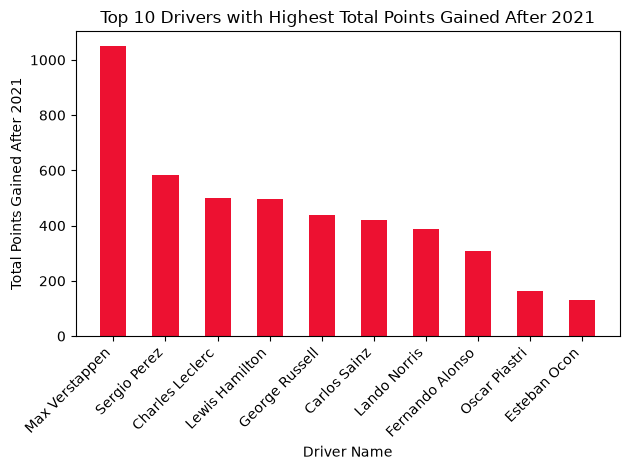

In [24]:
plt.bar(results_analysis_after_2021["full_name"], results_analysis_after_2021["sum_of_points_after_2021"], color='#ED1131', width=0.5)
plt.title("Top 10 Drivers with Highest Total Points Gained After 2021")
plt.xlabel("Driver Name")
plt.ylabel("Total Points Gained After 2021")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now, lets see the same graph of waffle

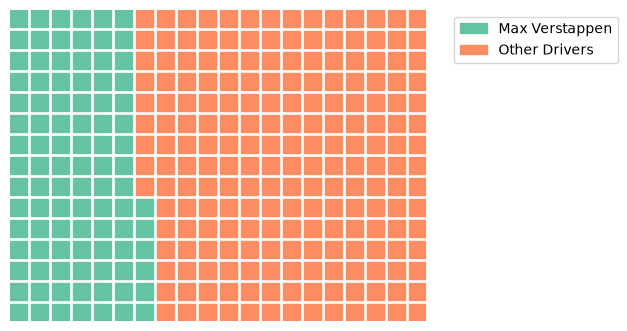

In [25]:
max_points_after_2021 = results_analysis_after_2021["sum_of_points_after_2021"].where(results_analysis_after_2021["full_name"]=="Max Verstappen").dropna().values[0]
data={
    "Max Verstappen": max_points,
    "Other Drivers": results_analysis_after_2021["sum_of_points_after_2021"].sum() - max_points
}
plt.figure(
    FigureClass=Waffle,
    rows=15,
    columns=20,
    values=data,
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
)
plt.show()

Now, we can see how the domination changed everything. Lets compare to the constructors again

In [26]:
results_analysis["sum_of_points_constructors_after_2021"] = results_analysis.where(lambda x: results_analysis["season"] > 2021).groupby("constructor_name")["points"].transform("sum")
top_gained_points_by_constructor_after_2021 = results_analysis[["constructor_name","sum_of_points_constructors_after_2021"]].drop_duplicates().sort_values(by="sum_of_points_constructors_after_2021", ascending=False).head(10)
top_gained_points_by_constructor_after_2021

,constructor_name,sum_of_points_constructors_after_2021
460,Red Bull Racing,1635.0
464,Mercedes,934.0
461,Ferrari,925.0
466,McLaren,585.0
471,Aston Martin,356.0
465,Alpine,264.0
470,Alfa Romeo,60.0
467,AlphaTauri,47.0
468,Haas F1 Team,43.0
473,Williams,36.0


After 2021 Max Verstappen gained more points than all teams(excluding his team), he can be compared only with the teams.

In [27]:
max_points_after_2021_df = pd.DataFrame({"constructor_name": ["Max Verstappen"], "sum_of_points_constructors_after_2021": max_points_after_2021})
top_gained_points_by_constructor_after_2021 = pd.concat([top_gained_points_by_constructor_after_2021, max_points_after_2021_df])
top_gained_points_by_constructor_after_2021 = top_gained_points_by_constructor_after_2021.sort_values(by="sum_of_points_constructors_after_2021",ascending=False)
top_gained_points_by_constructor_after_2021 = top_gained_points_by_constructor_after_2021.drop(top_gained_points_by_constructor_after_2021[top_gained_points_by_constructor_after_2021['constructor_name'] == "Red Bull Racing"].index)
top_gained_points_by_constructor_after_2021.head(10)

,constructor_name,sum_of_points_constructors_after_2021
0,Max Verstappen,1051.0
464,Mercedes,934.0
461,Ferrari,925.0
466,McLaren,585.0
471,Aston Martin,356.0
465,Alpine,264.0
470,Alfa Romeo,60.0
467,AlphaTauri,47.0
468,Haas F1 Team,43.0
473,Williams,36.0


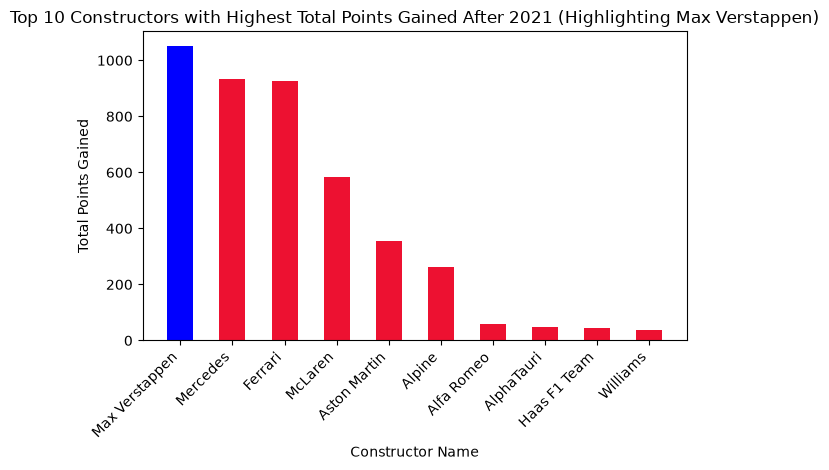

In [28]:
plt.bar(top_gained_points_by_constructor_after_2021["constructor_name"], top_gained_points_by_constructor_after_2021["sum_of_points_constructors_after_2021"], width=0.5, color=['blue' if name == "Max Verstappen" else '#ED1131' for name in top_gained_points_by_constructor_after_2021["constructor_name"]])
plt.title("Top 10 Constructors with Highest Total Points Gained After 2021 (Highlighting Max Verstappen)")
plt.xlabel("Constructor Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Let's Investigate how the situation in the driver standings looked in the most competing year - 2021

In [ ]:
results_analysis_2021 = results_analysis[results_analysis["season"] == 2021].copy()
results_analysis_2021 = results_analysis_2021[["full_name","points","season","race_name"]]
results_analysis_2021.head(10)



,full_name,points,season,race_name
0,Lewis Hamilton,25.0,2021,Bahrain Grand Prix
1,Max Verstappen,18.0,2021,Bahrain Grand Prix
2,Valtteri Bottas,16.0,2021,Bahrain Grand Prix
3,Lando Norris,12.0,2021,Bahrain Grand Prix
4,Sergio Perez,10.0,2021,Bahrain Grand Prix
5,Charles Leclerc,8.0,2021,Bahrain Grand Prix
6,Daniel Ricciardo,6.0,2021,Bahrain Grand Prix
7,Carlos Sainz,4.0,2021,Bahrain Grand Prix
8,Yuki Tsunoda,2.0,2021,Bahrain Grand Prix
9,Lance Stroll,1.0,2021,Bahrain Grand Prix
